In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Load the data
# Replace 'microsoft_stocks.csv' with the actual file name if different
df = pd.read_csv('/content/MSFT.csv', index_col='Date', parse_dates=True)

# Perform the ADF test
def adf_test(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

# Apply the test to the 'Close' price column
adf_test(df['Close'])

# Interpret the results
print('\nInterpretation:')
print('If the Test Statistic is less than the Critical Values and the p-value is less than 0.05, the time series is considered stationary.')

Results of Dickey-Fuller Test:
Test Statistic                    5.344103
p-value                           1.000000
#Lags Used                       38.000000
Number of Observations Used    9044.000000
Critical Value (1%)              -3.431073
Critical Value (5%)              -2.861860
Critical Value (10%)             -2.566940
dtype: float64

Interpretation:
If the Test Statistic is less than the Critical Values and the p-value is less than 0.05, the time series is considered stationary.


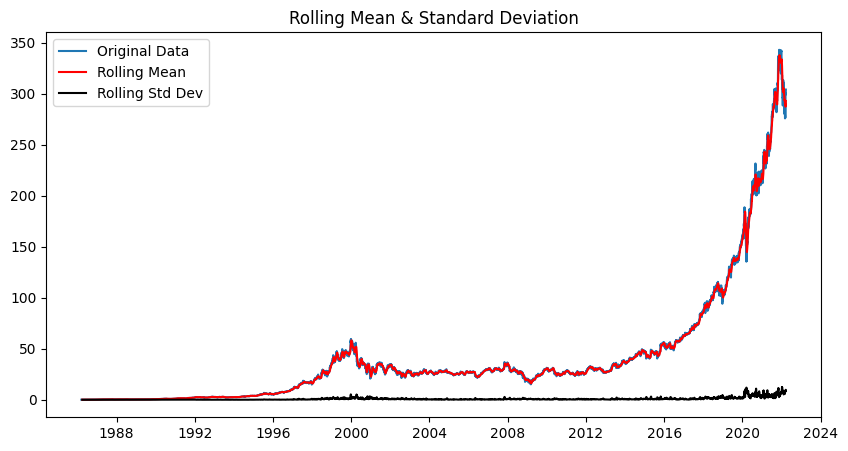

ADF Test Statistic: 5.344103354680442
P-value: 1.0
Critical Values: {'1%': np.float64(-3.431073259288842), '5%': np.float64(-2.861859633861699), '10%': np.float64(-2.5669401360673)}
The data is non-stationary (Fail to Reject H0).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Load the dataset
df = pd.read_csv("/content/MSFT.csv")  # Replace with your actual file path

# Convert 'Date' column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.set_index('Date', inplace=True)

# Select the stock price column (e.g., 'Close')
stock_price_col = "Close"  # Replace with the actual column name if different

# Plot rolling statistics
plt.figure(figsize=(10, 5))
plt.plot(df[stock_price_col], label="Original Data")
plt.plot(df[stock_price_col].rolling(window=12).mean(), label="Rolling Mean", color='red')
plt.plot(df[stock_price_costd(), label="Rolling Std Dev", color='black')
plt.legend()
plt.title("Rolling Mean & Standard Deviation")
plt.show()

# Augmented Dickey-Fuller (ADF) Test
result = adfuller(df[stock_price_col].dropna())
print(f"ADF Test Statistic: {result[0]}")
print(f"P-value: {result[1]}")
print("Critical Values:", result[4])

# Interpret the results
if result[1] < 0.05:
    print("The data is stationary (Reject H0).")
else:
    print("The data is non-stationary (Fail to Reject H0).")